In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('../data/netflix_clean.csv')
print(df.shape)
print(df['type'].value_counts())

(8807, 18)
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [2]:
# duration_unit aur type ka rishta dekho
print(pd.crosstab(df['duration_unit'], df['type']))

type           Movie  TV Show
duration_unit                
Season             0     2676
min             6128        0


## Data Leakage ka problem

`duration_unit` column type ko 100% predict kar deta hai:
- `min` → hamesha Movie (6128 mein se 6128)
- `Season` → hamesha TV Show (2676 mein se 2676)

Agar ye feature model ko diya jaye to 100% accuracy aayegi, lekin model ne
kuch seekha nahi hoga — sirf ek rule yaad kar liya hoga. Isay **data
leakage** kehte hain.

Is liye `duration_unit` aur `duration_num` dono model se nikal rahe hain.
Accuracy kam aayegi lekin model asal mein kaam ka hoga.

Aage dono tarah ke natije dikhaye gaye hain — leakage ke sath aur bagair —
taake farq saaf nazar aaye.

In [3]:
# Sirf wo features jo asal mein kaam ke hain
data = df[['type', 'release_year', 'rating', 'year_added', 'listed_in']].copy()

# Missing hatao
data = data.dropna()

# Pehla genre nikalo
data['main_genre'] = data['listed_in'].str.split(', ').str[0]
data = data.drop('listed_in', axis=1)

# Sirf top 15 genres rakho, baqi "Other"
top15 = data['main_genre'].value_counts().head(15).index
data['main_genre'] = data['main_genre'].where(data['main_genre'].isin(top15), 'Other')

print(data.shape)
print(data.head())

(8797, 5)
      type  release_year rating  year_added              main_genre
0    Movie          2020  PG-13      2021.0           Documentaries
1  TV Show          2021  TV-MA      2021.0  International TV Shows
2  TV Show          2021  TV-MA      2021.0          Crime TV Shows
3  TV Show          2021  TV-MA      2021.0              Docuseries
4  TV Show          2021  TV-MA      2021.0  International TV Shows


In [4]:
# Jawab (target) alag karo
y = (data['type'] == 'TV Show').astype(int)   # 1 = TV Show, 0 = Movie

# Features
X = data.drop('type', axis=1)

# Text columns ko numbers banao
X = pd.get_dummies(X, columns=['rating', 'main_genre'], drop_first=True)

print("Features ki tadaad:", X.shape[1])
print("Rows:", X.shape[0])
print("\nTV Show:", y.sum(), "| Movie:", (y == 0).sum())

Features ki tadaad: 34
Rows: 8797

TV Show: 2666 | Movie: 6131


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training:", X_train.shape[0], "rows")
print("Testing:", X_test.shape[0], "rows")
print("\nTraining mein TV Show ka hissa:", round(y_train.mean() * 100, 1), "%")
print("Testing mein TV Show ka hissa:", round(y_test.mean() * 100, 1), "%")

Training: 7037 rows
Testing: 1760 rows

Training mein TV Show ka hissa: 30.3 %
Testing mein TV Show ka hissa: 30.3 %


In [6]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Logistic Regression accuracy:", round(accuracy_score(y_test, lr_pred), 3))
print("Random Forest accuracy:      ", round(accuracy_score(y_test, rf_pred), 3))

Logistic Regression accuracy: 0.983
Random Forest accuracy:       0.989


In [7]:
print(pd.crosstab(data['main_genre'], data['type']))

type                      Movie  TV Show
main_genre                              
Action & Adventure          859        0
Anime Series                  0      175
British TV Shows              0      252
Children & Family Movies    605        0
Comedies                   1210        0
Crime TV Shows                0      399
Documentaries               829        0
Docuseries                    0      220
Dramas                     1600        0
Horror Movies               275        0
International Movies        128        0
International TV Shows        0      773
Kids' TV                      0      386
Other                       291      341
Reality TV                    0      120
Stand-Up Comedy             334        0


In [8]:
# Sirf rating aur saal — genre nikal do
X2 = X[[c for c in X.columns if not c.startswith('main_genre')]]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

lr2 = LogisticRegression(max_iter=1000, class_weight='balanced')
lr2.fit(X2_train, y2_train)
lr2_pred = lr2.predict(X2_test)

rf2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf2.fit(X2_train, y2_train)
rf2_pred = rf2.predict(X2_test)

print("Features ab:", X2.shape[1], "(pehle 34 the)")
print("\nGenre ke BAGAIR:")
print("  Logistic Regression:", round(accuracy_score(y2_test, lr2_pred), 3))
print("  Random Forest:      ", round(accuracy_score(y2_test, rf2_pred), 3))

C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Features ab: 19 (pehle 34 the)

Genre ke BAGAIR:
  Logistic Regression: 0.539
  Random Forest:       0.672


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Baseline: sab ko Movie keh do
baseline = 1 - y2_test.mean()
print("Baseline (sab Movie):", round(baseline, 3))

# Scaling ke sath dobara
lr3 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced'))
lr3.fit(X2_train, y2_train)
lr3_pred = lr3.predict(X2_test)

print("\nNATIJA:")
print("  Baseline:            ", round(baseline, 3))
print("  Logistic (scaled):   ", round(accuracy_score(y2_test, lr3_pred), 3))
print("  Random Forest:       ", round(accuracy_score(y2_test, rf2_pred), 3))

Baseline (sab Movie): 0.697

NATIJA:
  Baseline:             0.697
  Logistic (scaled):    0.536
  Random Forest:        0.672


=== RANDOM FOREST (genre ke bagair) ===
              precision    recall  f1-score   support

       Movie       0.83      0.66      0.74      1227
     TV Show       0.47      0.70      0.56       533

    accuracy                           0.67      1760
   macro avg       0.65      0.68      0.65      1760
weighted avg       0.72      0.67      0.68      1760



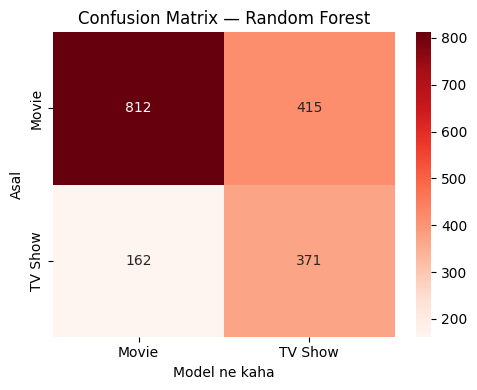

In [10]:
print("=== RANDOM FOREST (genre ke bagair) ===")
print(classification_report(y2_test, rf2_pred, target_names=['Movie', 'TV Show']))

cm = confusion_matrix(y2_test, rf2_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Movie', 'TV Show'], yticklabels=['Movie', 'TV Show'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Asal')
plt.xlabel('Model ne kaha')
plt.tight_layout()
plt.savefig('../screenshots/06_confusion_matrix.png', dpi=150)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11884\925658948.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Reds_r')


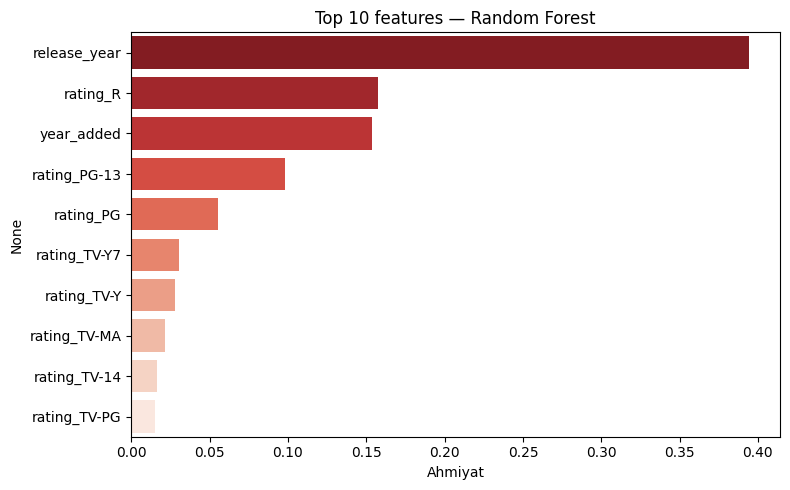

release_year    0.394
rating_R        0.158
year_added      0.154
rating_PG-13    0.098
rating_PG       0.055
rating_TV-Y7    0.031
rating_TV-Y     0.028
rating_TV-MA    0.021
rating_TV-14    0.016
rating_TV-PG    0.015
dtype: float64


In [11]:
importances = pd.Series(rf2.feature_importances_, index=X2.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='Reds_r')
plt.title('Top 10 features — Random Forest')
plt.xlabel('Ahmiyat')
plt.tight_layout()
plt.savefig('../screenshots/07_feature_importance.png', dpi=150)
plt.show()

print(importances.round(3))

## Task 5 — Summary

### Do leaks mile

**Leak 1: `duration_unit`** — `min` hamesha Movie, `Season` hamesha TV Show.
100% perfect split.

**Leak 2: genre** — Netflix ke genre names hi alag hain. "Dramas" sirf
movies mein, "TV Dramas" sirf TV shows mein. Sirf "Other" mein dono the.

### Natije

| Setup | Logistic | Random Forest |
|---|---|---|
| Genre ke sath (leak) | 0.983 | 0.989 |
| Genre ke bagair (saaf) | 0.536 | 0.672 |
| Baseline (sab Movie) | — | 0.697 |

### important point: accuracy jhoot bol rahi thi

Random Forest ki accuracy (0.672) baseline (0.697) se kam hai. Dekhne mein
lagta hai model bekaar hai. Lekin:

| | Accuracy | TV Shows pakre |
|---|---|---|
| Baseline | 0.697 | **0 / 533** |
| Random Forest | 0.672 | **371 / 533** |

Baseline sab ko Movie kehta hai — accuracy achhi lagti hai lekin ek bhi
TV Show nahi pakarta. Hamara model TV Show ka recall **0.70** deta hai.

**Sabaq:** imbalanced data mein accuracy ghalat paimana hai. Recall aur
F1-score dekhna zaroori hai.

### Feature importance
`release_year` (0.394) sab se ahem. Uske baad `rating_R` (0.158) aur
`rating_PG-13` (0.098) — ye cinema ratings hain jo TV shows ko nahi miltin,
is liye achha signal dete hain.

### Last point
Leak-free features se Movie vs TV Show ka andaza lagana taqreeban namumkin
hai. Ye nakami nahi — ye khud ek finding hai.